# 7장. 그래프로 데이터의 이야기를 보여주기

이 노트북의 목표는 그래프를 많이 만드는 것이 아닙니다. **분석 질문에 맞는 그래프를 선택하고, 그래프에 들어간 데이터 범위와 수치를 검증하며, 그래프가 보여 주는 사실과 보여 주지 못하는 것을 구분하는 것**이 핵심입니다.

금액성 그래프는 기본적으로 `order_status == "completed"` 범위를 사용합니다. `line_total`은 주문 상세 한 행의 `quantity × unit_price`이며 회계상 순매출로 단정하지 않습니다.

## 0. 사용 방법

- 위에서부터 차례대로 실행합니다.
- 입력은 Chapter 05에서 만든 `data/processed/*_clean.csv`입니다.
- 파일이 없다면 프로젝트 루트에서 `python scripts/preprocess_data.py`를 먼저 실행합니다.
- 그래프를 보기 전에 **시각화용 집계 검증표**를 먼저 확인합니다.
- 대표 그래프마다 `관찰 → 해석 → 한계 → 다음 질문`을 Markdown 셀에 직접 작성합니다.
- 실제 실행 결과 숫자를 보고 작성하며 강의안의 예시를 정답처럼 사용하지 않습니다.

## 1. 질문에 맞는 그래프를 먼저 고릅니다

| 분석 질문 | 그래프 | 데이터 범위 |
| --- | --- | --- |
| 카테고리별 완료 주문 금액은 어떻게 다른가? | 막대그래프 | completed 주문 상세 |
| 월별 완료 주문 금액은 어떻게 변하는가? | 선그래프 | completed + 유효한 주문일 |
| 상품 가격은 어느 구간에 몰려 있는가? | 히스토그램 | 전체 상품 마스터 |
| 상품 가격과 완료 주문 판매 수량은 어떤 패턴인가? | 산점도 | completed 상품 집계 |
| 완료 주문 구매 금액 상위 고객군은 어떻게 구성되는가? | 가로 막대그래프 | completed 고객 집계 |
| 주문 상태별 주문 수는 어떻게 다른가? | 막대그래프 | 전체 orders |

> 그래프 종류보다 먼저 **질문과 데이터 범위**를 고정합니다.

In [2]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        folder
        for folder in [CURRENT_DIR, *CURRENT_DIR.parents]
        if (folder / "data" / "processed").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "data/processed 폴더를 포함한 프로젝트 루트를 찾지 못했습니다."
    )
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("현재 실행 위치:", CURRENT_DIR)
print("프로젝트 루트:", PROJECT_ROOT)
print("전처리 데이터 폴더:", PROCESSED_DIR)
print("그래프 저장 폴더:", FIGURE_DIR)

현재 실행 위치: C:\dev\ai-data-analysis\00_llm-data-analysis-course\practice\chapter07
프로젝트 루트: C:\dev\ai-data-analysis\00_llm-data-analysis-course
전처리 데이터 폴더: C:\dev\ai-data-analysis\00_llm-data-analysis-course\data\processed
그래프 저장 폴더: C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\figures


## 2. 검증된 시각화용 데이터를 준비합니다

공통 모듈은 그래프를 그리기 전에 다음을 검사합니다.

- 필수 컬럼
- PK 결측·중복
- `many_to_one` 병합
- 주문/상품 미매칭
- 숫자형 변환 실패
- `completed` 주문 범위
- 카테고리·상품·고객·월별 집계 총합

문제가 있으면 그래프를 만들기 전에 중단합니다.

In [3]:
from src.visualization import (
    prepare_visualization_data,
    setup_korean_font,
)

selected_font = setup_korean_font()
print("사용 한글 폰트:", selected_font or "자동 선택 실패 — 설치된 한글 폰트 확인 필요")

viz_data = prepare_visualization_data(PROCESSED_DIR)

products = viz_data["products"]
orders = viz_data["orders"]
completed_order_sales = viz_data["completed_order_sales"]
category_sales = viz_data["category_sales"]
monthly_sales = viz_data["monthly_sales"]
product_sales = viz_data["product_sales"]
customer_sales = viz_data["customer_sales"]
order_status = viz_data["order_status"]

print("완료 주문 상세 행:", len(completed_order_sales))
print(
    "월별 집계에서 제외되는 날짜 결측 완료 주문 상세:",
    len(viz_data["invalid_date_sales"]),
)

사용 한글 폰트: Malgun Gothic
완료 주문 상세 행: 474
월별 집계에서 제외되는 날짜 결측 완료 주문 상세: 0


In [4]:
viz_data["visualization_validation"]

,check,expected,actual,difference,passed
0,category_completed_amount,148990000.0,148990000.0,0.0,True
1,product_completed_amount,148990000.0,148990000.0,0.0,True
2,customer_completed_amount,148990000.0,148990000.0,0.0,True
3,monthly_completed_amount_valid_dates,148990000.0,148990000.0,0.0,True


### 검증 결과 기록

`passed`가 모두 `True`인지 확인한 뒤 아래 내용을 자신의 말로 작성합니다.

- **총합 검증 결과:** 카테고리별, 상품별, 고객별, 월별 completed 주문 금액 집계가 모두 기준 합계 **148,990,000원**과 일치했다. 검증표의 모든 `passed` 값은 `True`였다.

- **문제가 있었다면 원인:** 이번 검증에서는 집계 불일치가 발견되지 않았다. 월별 집계에서 날짜 결측으로 제외된 completed 주문 상세도 **0건**이었다.

- **시각화를 진행해도 된다고 판단한 이유:** 금액성 그래프의 분석 범위를 `order_status == "completed"`로 통일했고, 완료 주문 상세 **474행**을 기준으로 만든 모든 집계가 같은 총합과 일치했다. 따라서 그래프에 사용하는 수치와 범위가 검증되었다고 판단했다.

## 3. 카테고리별 완료 주문 금액 — 막대그래프

범주별 크기 비교이므로 막대그래프를 사용합니다. 값 축은 0에서 시작합니다. 금액이 크다는 사실만으로 선호도가 높다고 단정하지 않습니다.

In [5]:
from src.visualization import plot_category_sales

category_sales[["category", "total_quantity", "completed_amount", "amount_ratio_pct"]]

,category,total_quantity,completed_amount,amount_ratio_pct
3,스포츠,295,31743000,21.31
5,전자기기,259,26400000,17.72
2,생활용품,272,23915000,16.05
1,뷰티,223,23383000,15.69
4,식품,133,16573000,11.12
0,도서,149,16389000,11.00
6,패션,111,10587000,7.11


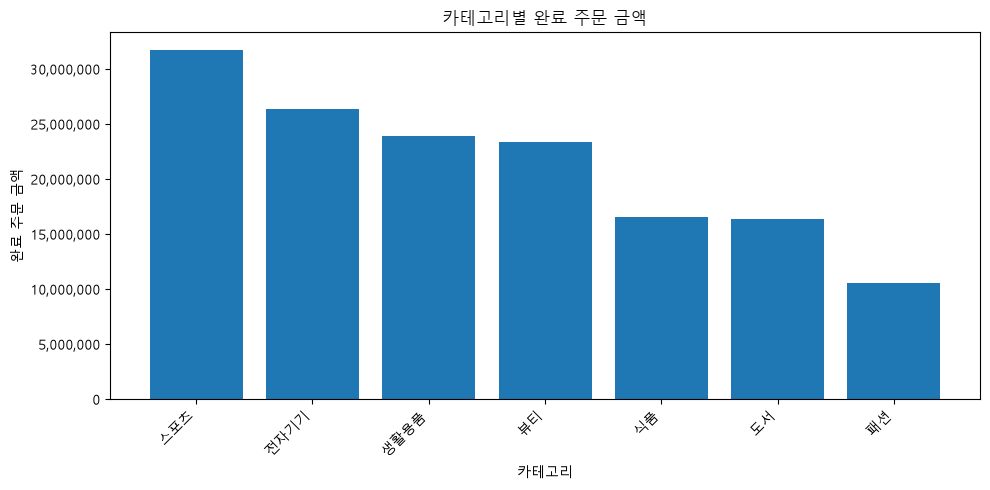

WindowsPath('C:/dev/ai-data-analysis/00_llm-data-analysis-course/reports/figures/ch07_category_completed_amount_bar.png')

In [6]:
category_path = plot_category_sales(
    category_sales,
    FIGURE_DIR / "ch07_category_completed_amount_bar.png",
    show=True,
)
category_path

### 그래프 1 기록

- **관찰:** 스포츠 카테고리의 completed 주문 금액은 31,743,000원으로 가장 높았고, 전체 금액의 21.31%를 차지했다. 패션 카테고리는 10,587,000원으로 가장 낮았다.

- **해석:** 스포츠 카테고리는 completed 주문 금액에서 가장 큰 비중을 차지한다. 다만 금액은 판매 수량과 단가가 함께 반영된 값이므로, 이것만으로 고객 선호도나 수익성이 가장 높다고 판단할 수는 없다.

- **한계:** 이 그래프는 completed 주문 금액만 보여 주며, 원가·마진·할인·환불 사유·고객 만족도는 반영하지 않는다.

- **다음 질문:** 카테고리별 판매 수량, 평균 판매 단가, 상품 수를 함께 비교했을 때도 스포츠 카테고리의 높은 금액 비중이 유지되는가?

## 4. 월별 완료 주문 금액 — 선그래프

시간 순서가 핵심인 질문이므로 선그래프를 사용합니다. 첫 달과 마지막 달이 완전한 한 달인지, 중간 월이 비어 있다면 실제 0인지 데이터 누락인지 확인합니다.

In [7]:
from src.visualization import plot_monthly_sales

monthly_sales[
    [
        "order_month",
        "completed_amount",
        "completed_order_count",
        "average_completed_order_amount",
    ]
]

,order_month,completed_amount,completed_order_count,average_completed_order_amount
0,2025-07,5869000,8,733625.0
1,2025-08,15621000,18,867833.0
2,2025-09,10190000,13,783846.0
3,2025-10,25766000,26,991000.0
4,2025-11,8812000,12,734333.0
5,2025-12,11501000,14,821500.0
6,2026-01,17423000,22,791955.0
7,2026-02,9749000,17,573471.0
8,2026-03,13429000,14,959214.0
9,2026-04,17553000,23,763174.0


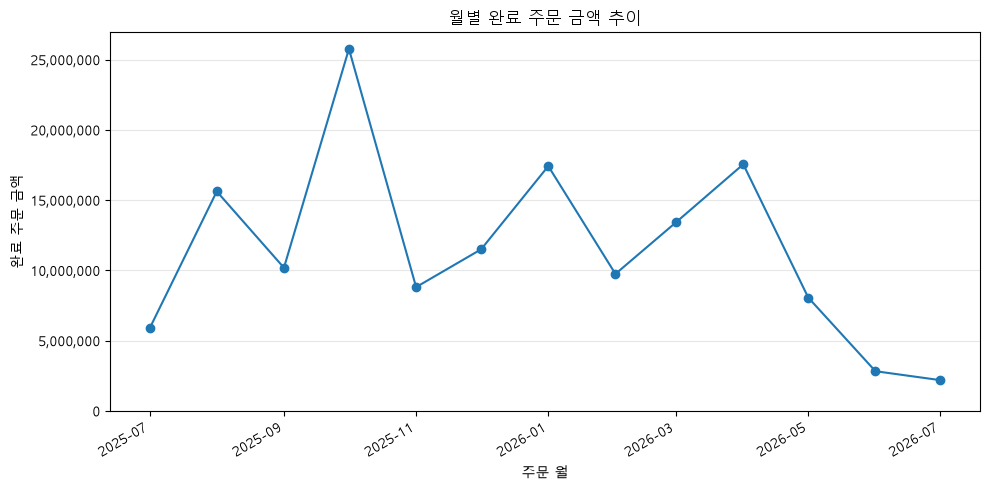

WindowsPath('C:/dev/ai-data-analysis/00_llm-data-analysis-course/reports/figures/ch07_monthly_completed_amount_line.png')

In [8]:
monthly_path = plot_monthly_sales(
    monthly_sales,
    FIGURE_DIR / "ch07_monthly_completed_amount_line.png",
    show=True,
)
monthly_path

### 그래프 2 기록

- **관찰:** 월별 completed 주문 금액은 2025년 10월에 25,766,000원으로 가장 높았고, 2026년 7월에는 2,188,000원으로 가장 낮았다. 2026년 4월 17,553,000원 이후 5월 8,063,000원, 6월 2,826,000원, 7월 2,188,000원으로 감소했다.

- **해석:** 2025년 10월과 2026년 1월·4월에 완료 주문 금액이 상대적으로 높게 나타났다. 2026년 4월 이후의 감소는 completed 주문 건수가 23건에서 11건, 4건, 2건으로 줄어든 흐름과 함께 확인된다. 다만 현재 결과만으로 감소 원인을 단정할 수는 없다.

- **한계:** 첫 달과 마지막 달이 완전한 한 달인지 확인하지 않았으므로, 해당 기간의 금액을 다른 달과 같은 조건으로 비교하기 어렵다. 또한 프로모션, 계절성, 재고, 상품 구성 등 금액 변화의 원인이 될 수 있는 정보는 현재 데이터에 없다.

- **다음 질문:** 월별 completed 주문 건수와 평균 주문 금액을 함께 비교했을 때, 월별 금액 변화는 주문 건수 변화와 평균 주문 금액 변화 중 어느 쪽의 영향을 더 크게 받는가?

## 5. 상품 가격 분포 — 히스토그램

상품 가격은 상품 마스터의 속성이므로 주문 상태와 무관하게 전체 상품을 봅니다. `bins` 값에 따라 모양이 달라질 수 있으므로 구간 수 하나만 보고 이상값을 확정하지 않습니다.

In [9]:
from src.visualization import plot_product_price_hist

products["price"].describe()

count       100.000000
mean     110040.000000
std       56433.910574
min        5000.000000
25%       65750.000000
50%      112000.000000
75%      161000.000000
max      200000.000000
Name: price, dtype: float64

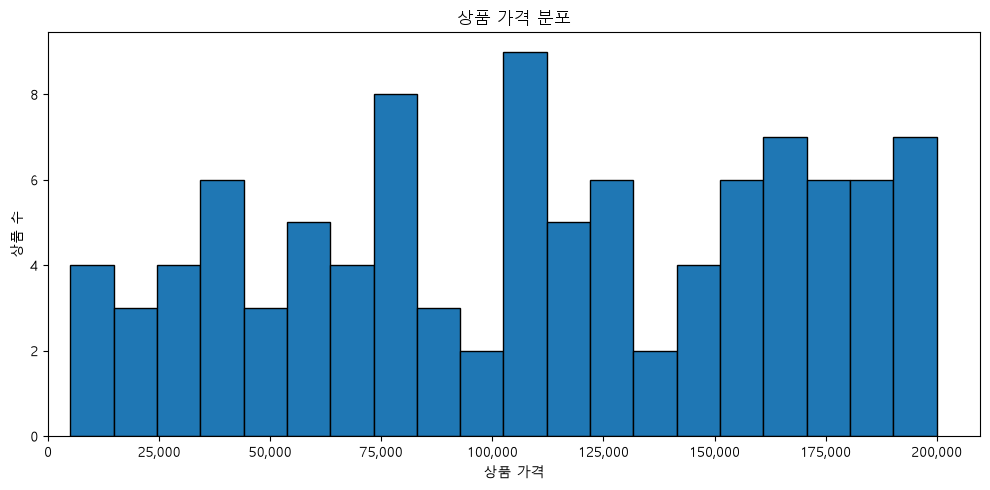

WindowsPath('C:/dev/ai-data-analysis/00_llm-data-analysis-course/reports/figures/ch07_product_price_hist.png')

In [16]:
price_hist_path = plot_product_price_hist(
    products,
    FIGURE_DIR / "ch07_product_price_hist.png",
    show=True,
    bins=20,
)
price_hist_path

### bins 비교 실습

`bins=10`, `20`, `30`으로 바꾸어 같은 데이터가 어떻게 다르게 보이는지 비교합니다.

- **공통 패턴:** bins를 10, 20, 30으로 바꾸어도 상품 가격은 약 5,000원부터 200,000원까지 넓게 분포했다. 특히 약 100,000원~120,000원 구간과 160,000원 이상 구간에 상대적으로 많은 상품이 분포하는 패턴이 공통적으로 확인됐다.

- **bins 선택에 따라 달라지는 인상:** bins=10에서는 넓은 가격대의 상품 수가 합쳐져 큰 흐름을 보기 쉽지만 세부적인 가격대 차이는 잘 드러나지 않았다. bins=20과 bins=30에서는 일부 좁은 구간의 높낮이가 더 뚜렷해 보이지만, 구간을 더 세분화할수록 작은 차이도 강조될 수 있다. 따라서 하나의 bins 설정만으로 특정 가격대가 절대적으로 많거나 이상값이라고 단정하지 않았다.

## 6. 상품 가격과 완료 주문 판매 수량 — 산점도

한 점은 상품 하나입니다. 관계가 보여도 **가격이 판매 수량의 원인**이라고 단정하지 않습니다.

In [17]:
from src.visualization import plot_price_quantity_scatter

product_sales[["price", "completed_quantity", "completed_amount"]].head(10)

,price,completed_quantity,completed_amount
39,163000,35,5705000
11,175000,25,4375000
8,193000,20,3860000
70,189000,20,3780000
69,161000,23,3703000
66,140000,26,3640000
78,165000,22,3630000
10,115000,31,3565000
20,112000,29,3248000
86,103000,30,3090000


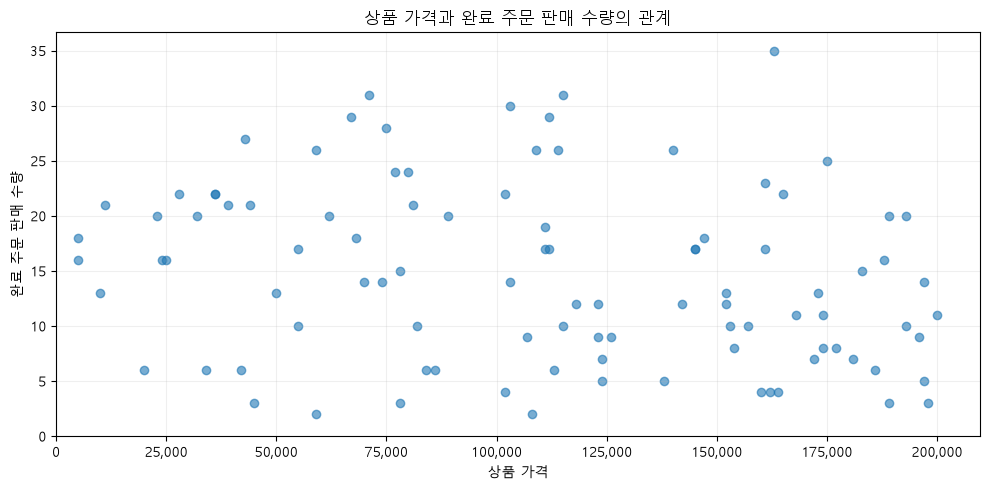

WindowsPath('C:/dev/ai-data-analysis/00_llm-data-analysis-course/reports/figures/ch07_price_completed_quantity_scatter.png')

In [18]:
scatter_path = plot_price_quantity_scatter(
    product_sales,
    FIGURE_DIR / "ch07_price_completed_quantity_scatter.png",
    show=True,
)
scatter_path

### 그래프 3 기록

- **관찰:** 상품 가격은 약 5,000원부터 200,000원까지 분포하고, completed 판매 수량은 약 2개부터 35개까지 분포했다. 같은 가격대에서도 판매 수량의 차이가 크며, 가격이 높아질수록 판매 수량이 일정하게 증가하거나 감소하는 뚜렷한 직선형 패턴은 보이지 않았다.

- **해석:** 현재 데이터에서는 상품 가격만으로 completed 판매 수량을 설명하기 어렵다. 일부 고가 상품의 판매 수량은 낮게 나타나지만, 약 163,000원 상품에서 판매 수량 35개가 나타나는 예외도 있으므로 가격과 판매 수량의 관계를 단순하게 해석할 수 없다.

- **한계:** 이 산점도는 가격과 판매 수량의 동시 분포만 보여 줄 뿐 가격이 판매 수량의 원인이라는 사실을 증명하지 않는다. 카테고리, 할인·프로모션, 재고, 상품 노출, 판매 기간 같은 변수는 반영하지 않았다.

- **다음 질문:** 카테고리별로 나누어 가격과 판매 수량을 비교했을 때도 같은 패턴이 나타나는가? 또한 할인 여부와 상품별 판매 기간을 함께 고려하면 판매 수량 차이를 더 잘 설명할 수 있는가?

## 7. 완료 주문 구매 금액 상위 고객 — 익명 가로 막대그래프

공개 그래프에서는 고객 이름이나 원본 고객 ID를 직접 표시하지 않고 **순위 기반 익명 라벨**을 사용합니다. Top 10은 전체 고객 분포가 아니라 일부 고객만 보여 줍니다.

In [19]:
from src.visualization import plot_top_customers

customer_sales[
    ["customer_id", "completed_order_count", "completed_amount", "average_completed_order_amount"]
].head(10)

,customer_id,completed_order_count,completed_amount,average_completed_order_amount
76,117,5,4100000,820000.0
62,102,4,3996000,999000.0
51,83,4,3880000,970000.0
21,30,5,3590000,718000.0
29,40,4,3523000,880750.0
13,20,2,3191000,1595500.0
0,3,2,3178000,1589000.0
70,111,3,3153000,1051000.0
42,66,4,3093000,773250.0
97,147,2,2990000,1495000.0


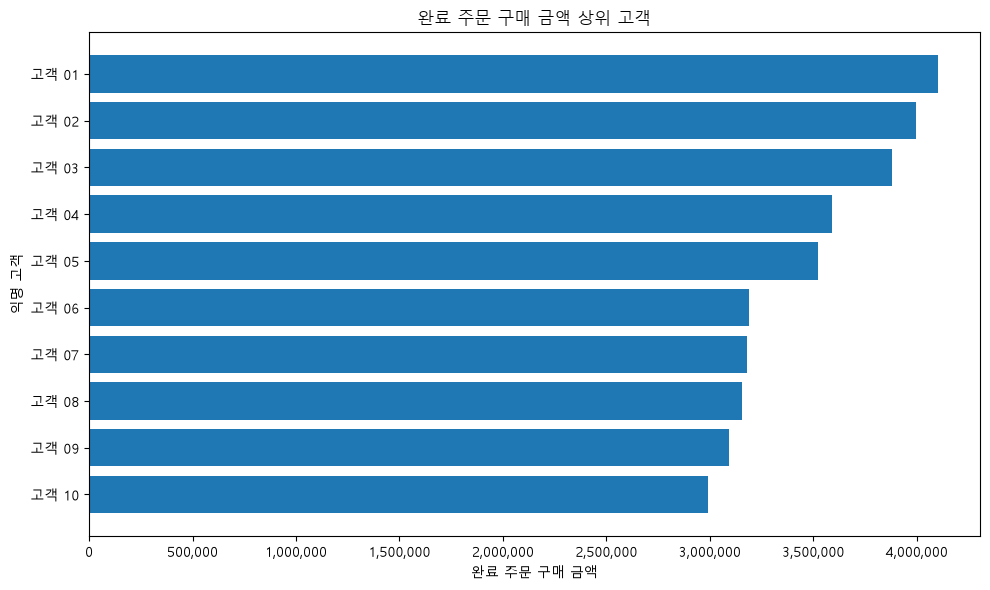

WindowsPath('C:/dev/ai-data-analysis/00_llm-data-analysis-course/reports/figures/ch07_top_customers_anonymized_barh.png')

In [20]:
top_customer_path = plot_top_customers(
    customer_sales,
    FIGURE_DIR / "ch07_top_customers_anonymized_barh.png",
    show=True,
    top_n=10,
)
top_customer_path

### 해석 주의

구매 금액이 높다고 바로 '충성 고객'이라고 부르지 않습니다.

- **반복 주문 횟수는 많은가?** 상위 10명 고객의 completed 주문 횟수는 2회~5회였다. 고객 01과 고객 04는 5회 주문했지만, 여러 고객은 2회 주문만으로 상위권에 포함되었다.

- **한 번의 큰 주문 때문인가?** 고객 06, 고객 07, 고객 10은 주문 횟수가 2회이지만 완료 주문 금액이 약 299만 원~319만 원으로 높다. 따라서 일부 고객의 높은 구매 금액은 적은 횟수의 고액 주문 영향일 수 있다.

- **평균 주문 금액은 어떤가?** 상위 고객의 평균 완료 주문 금액은 약 718,000원~1,595,500원으로 차이가 있다. 구매 금액 순위는 반복 주문 횟수뿐 아니라 한 번의 주문 금액에도 영향을 받는다.

- **분석 기간이 충분한가?** 현재 데이터는 2025년 7월부터 2026년 7월까지의 주문을 기준으로 한다. 다만 첫 달과 마지막 달의 데이터가 완전한 한 달인지 확인하지 않았으므로, 이 결과만으로 장기적인 충성 고객이라고 단정할 수 없다.

## 8. 전체 주문 상태 — 막대그래프

이 그래프만 전체 주문을 사용합니다. 상태별 규모는 보여 주지만 취소·환불의 원인을 설명하지 않습니다.

In [21]:
from src.visualization import plot_order_status

order_status

,order_status,order_count
0,completed,184
1,cancelled,64
2,refunded,52


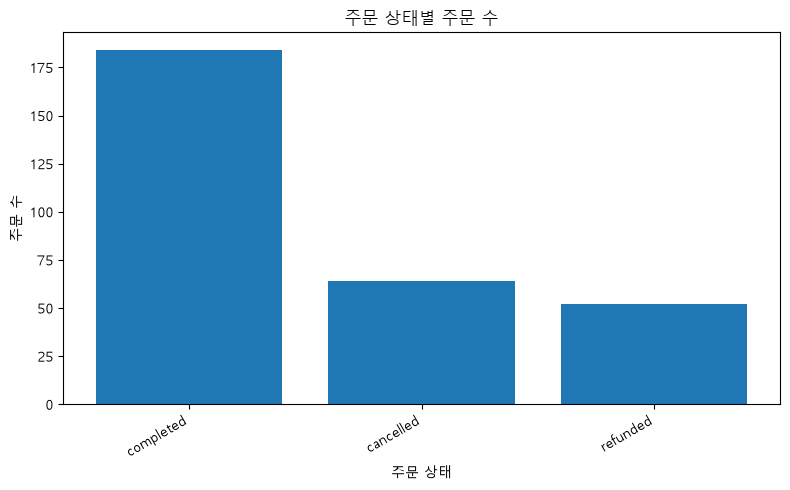

WindowsPath('C:/dev/ai-data-analysis/00_llm-data-analysis-course/reports/figures/ch07_order_status_bar.png')

In [22]:
order_status_path = plot_order_status(
    order_status,
    FIGURE_DIR / "ch07_order_status_bar.png",
    show=True,
)
order_status_path

## 9. 그래프와 숫자를 교차 검증합니다

대표 그래프 3개 이상에 대해 다음을 확인합니다.

```text
그래프에 표시된 값
=
그래프 원본 집계표의 값
```

또한 다음을 점검합니다.

- **축 이름과 단위가 맞는가?** 카테고리·주문 월·상품 가격·완료 주문 판매 수량 등 각 축 이름이 분석 대상을 설명한다. 금액성 값은 원(₩) 기준의 완료 주문 금액이다.

- **범주 정렬과 날짜 정렬이 맞는가?** 카테고리 그래프는 완료 주문 금액이 큰 순서로 정렬되어 있고, 월별 그래프는 2025년 7월부터 2026년 7월까지 시간 순서로 정렬되어 있다.

- **막대그래프 값 축이 불필요하게 잘리지 않았는가?** 카테고리별 완료 주문 금액 막대그래프의 값 축은 0에서 시작하므로 카테고리 간 차이가 과장되지 않았다.

- **제목이 실제 분석 범위를 반영하는가?** 금액성 그래프의 제목에는 완료 주문 기준이라는 범위가 포함되어 있고, 주문 상태 그래프는 전체 주문의 상태별 주문 수를 나타낸다.

- **데이터가 없는 구간을 임의로 0으로 만들지 않았는가?** 월별 집계에서 날짜 결측으로 제외된 완료 주문 상세는 0건이었고, 날짜가 없는 구간을 임의로 0으로 추가하지 않았다.

## 10. 공통 함수로 전체 그래프와 보고서를 다시 생성합니다

Notebook에서 개별 그래프를 이해한 뒤 공통 함수를 사용해 같은 결과를 재현합니다.

In [23]:
from src.visualization import (
    build_visualization_report,
    create_all_figures,
    create_visualization_summary,
)

saved_figures = create_all_figures(viz_data, FIGURE_DIR, show=False)
summary = create_visualization_summary()

summary_path = REPORT_DIR / "ch07_visualization_summary.md"
summary_path.write_text(
    build_visualization_report(summary),
    encoding="utf-8",
)

print("생성 파일")
for path in saved_figures:
    print("-", path)

print("요약 보고서:", summary_path)
summary

생성 파일
- C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\figures\ch07_category_completed_amount_bar.png
- C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\figures\ch07_monthly_completed_amount_line.png
- C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\figures\ch07_product_price_hist.png
- C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\figures\ch07_price_completed_quantity_scatter.png
- C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\figures\ch07_top_customers_anonymized_barh.png
- C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\figures\ch07_order_status_bar.png
요약 보고서: C:\dev\ai-data-analysis\00_llm-data-analysis-course\reports\ch07_visualization_summary.md


,chart,question,scope,interpretation_point,file_name
0,카테고리별 완료 주문 금액,카테고리별 완료 주문 금액은 어떻게 다른가?,completed orders,금액 차이는 수량·단가 등 추가 지표로 확인,ch07_category_completed_amount_bar.png
1,월별 완료 주문 금액,월별 완료 주문 금액은 어떻게 변하는가?,completed orders + valid order_date,증감은 관찰이며 원인은 추가 데이터 필요,ch07_monthly_completed_amount_line.png
2,상품 가격 분포,상품 가격은 어떤 구간에 몰려 있는가?,product master,상품 구성 분포이며 판매 선호를 의미하지 않음,ch07_product_price_hist.png
3,상품 가격과 완료 주문 판매 수량,상품 가격과 완료 주문 판매 수량은 어떤 패턴을 보이는가?,completed orders aggregated by product,관계는 인과를 의미하지 않음,ch07_price_completed_quantity_scatter.png
4,완료 주문 구매 금액 상위 고객,완료 주문 구매 금액 상위 고객군은 어떻게 구성되는가?,completed orders aggregated by customer,Top N이며 충성도를 자동 의미하지 않음,ch07_top_customers_anonymized_barh.png
5,주문 상태별 주문 수,주문 상태별 주문 수는 어떻게 다른가?,all orders,상태 분포만으로 취소·환불 원인을 알 수 없음,ch07_order_status_bar.png


## 11. Chapter 07 최종 판단

### 가장 중요한 그래프 1개와 이유

카테고리별 완료 주문 금액 막대그래프가 가장 중요하다고 판단했다. completed 주문 금액이 어떤 카테고리에 집중되어 있는지 한눈에 비교할 수 있고, 이후 판매 수량·평균 단가·상품 수를 추가 분석할 기준을 제공하기 때문이다.

### 그래프에서 직접 확인한 사실

스포츠 카테고리의 completed 주문 금액은 31,743,000원으로 전체의 21.31%를 차지해 가장 높았다. 패션 카테고리는 10,587,000원으로 전체의 7.11%를 차지해 가장 낮았다.

### 내가 해석한 내용

스포츠 카테고리는 현재 분석 범위에서 완료 주문 금액 비중이 가장 큰 카테고리다. 따라서 카테고리별 매출 구성과 상품 운영을 검토할 때 우선적으로 확인할 대상이라고 판단했다.

### 그래프만으로 말할 수 없는 것

완료 주문 금액이 높다는 사실만으로 고객 선호도, 수익성, 고객 만족도, 재구매 가능성이 가장 높다고 말할 수는 없다. 판매 수량, 평균 단가, 원가, 할인, 환불 등의 정보를 함께 확인해야 한다.

### 오해를 줄이기 위해 수정하거나 확인한 요소

- **축:** 카테고리 그래프는 가로축에 카테고리, 세로축에 완료 주문 금액을 표시하는지 확인했다.
- **단위:** 금액성 그래프의 수치는 원(₩) 기준의 완료 주문 금액임을 확인했다.
- **정렬:** 카테고리 그래프는 완료 주문 금액이 큰 순서로, 월별 그래프는 시간 순서로 정렬된 것을 확인했다.
- **범위:** 금액성 그래프에는 completed 주문만 사용했고, 월별 그래프의 첫 달과 마지막 달은 부분 기간일 가능성을 해석의 한계로 반영했다.
- **개인정보:** 상위 고객 그래프는 고객 이름이나 원본 ID 대신 순위 기반 익명 라벨을 사용했다.

### 다음 분석에서 확인하고 싶은 질문

스포츠 카테고리의 높은 완료 주문 금액은 판매 수량이 많기 때문인지, 평균 판매 단가가 높기 때문인지, 또는 상품 수가 많기 때문인지 확인하고 싶다. 또한 카테고리별 원가·할인·환불 정보를 함께 분석해 실제 수익성과 고객 구매 패턴을 비교하고 싶다.

---

## 완료 체크

- [x] 질문을 그래프보다 먼저 정했습니다.
- [x] 금액성 그래프에 `completed` 주문 범위를 적용했습니다.
- [x] 집계 검증표의 `passed`를 확인했습니다.
- [x] 대표 그래프 3개 이상을 만들었습니다.
- [x] 그래프와 원본 집계값을 교차 확인했습니다.
- [x] 축·단위·정렬·범위를 확인했습니다.
- [x] 관계를 원인으로 단정하지 않았습니다.
- [x] 고객 그래프에서 개인정보를 직접 노출하지 않았습니다.
- [x] 그래프별 관찰·해석·한계·다음 질문을 작성했습니다.
- [x] `reports/figures`와 요약 보고서가 재생성되는지 확인했습니다.

다음 Chapter 08에서는 전처리, EDA, 시각화와 보고서를 하나의 작은 분석 프로젝트로 연결합니다.